### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

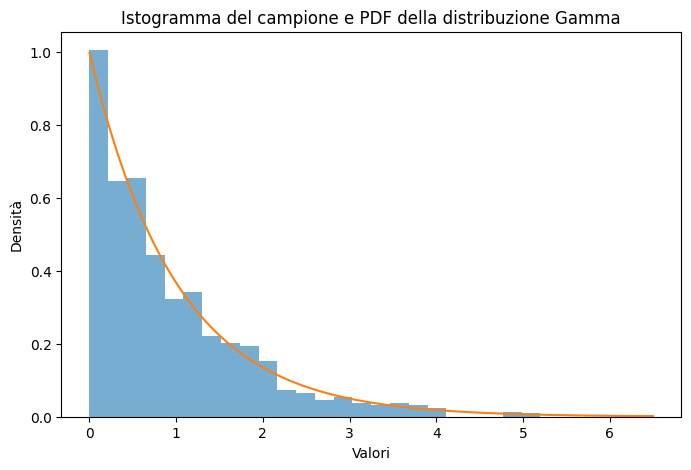

Parametri stimati:
(np.float64(0.9722546983670484), np.float64(0.0009037618651918185), np.float64(0.9719680117362215))
Parametro di forma stimato: 0.9722546983670484
Loc stimato: 0.0009037618651918185
Scale stimato: 0.9719680117362215


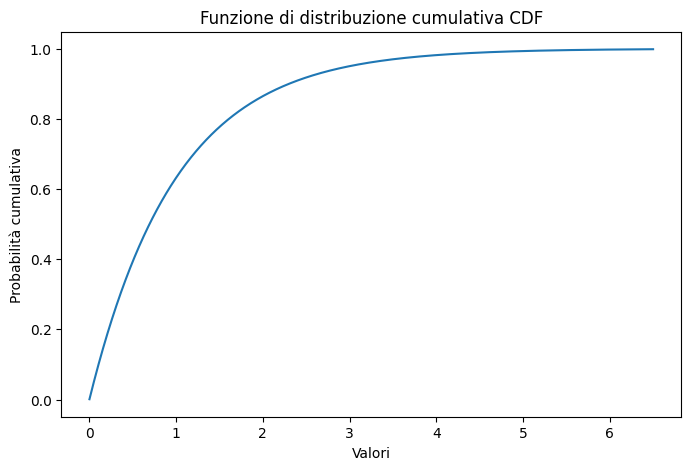

Varianza teorica: 1.0
Varianza del campione: 0.8374997540434306


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

gamma_dist = stats.gamma(a=1)

campione = gamma_dist.rvs(size=1000)

x = np.linspace(campione.min(), campione.max(), 1000)
pdf = gamma_dist.pdf(x)

plt.figure(figsize=(8, 5))
plt.hist(campione, bins=30, density=True, alpha=0.6)
plt.plot(x, pdf)
plt.title("Istogramma del campione e PDF della distribuzione Gamma")
plt.xlabel("Valori")
plt.ylabel("Densità")
plt.show()

parametri_stimati = stats.gamma.fit(campione)

print("Parametri stimati:")
print(parametri_stimati)

forma_stimata = parametri_stimati[0]
loc_stimato = parametri_stimati[1]
scale_stimato = parametri_stimati[2]

print("Parametro di forma stimato:", forma_stimata)
print("Loc stimato:", loc_stimato)
print("Scale stimato:", scale_stimato)

cdf = gamma_dist.cdf(x)

plt.figure(figsize=(8, 5))
plt.plot(x, cdf)
plt.title("Funzione di distribuzione cumulativa CDF")
plt.xlabel("Valori")
plt.ylabel("Probabilità cumulativa")
plt.show()

varianza_teorica = gamma_dist.var()
varianza_campione = campione.var()

print("Varianza teorica:", varianza_teorica)
print("Varianza del campione:", varianza_campione)

### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

Risultati temperatura massima:
Grado | MAE | RMSE
[[1.         7.25       7.79798477]
 [2.         2.58179321 2.96016046]
 [3.         2.56593407 2.89544753]
 [4.         0.78117716 0.93010389]
 [5.         0.65213218 0.76047915]]
Risultati temperatura minima:
Grado | MAE | RMSE
[[ 1.         16.38189588 18.00681905]
 [ 2.          7.52097902  8.53390332]
 [ 3.          6.35884486  7.41948058]
 [ 4.          2.95697358  3.48791249]
 [ 5.          1.72662142  2.29422949]]
Miglior grado per temp_max: 5
Miglior grado per temp_min: 5


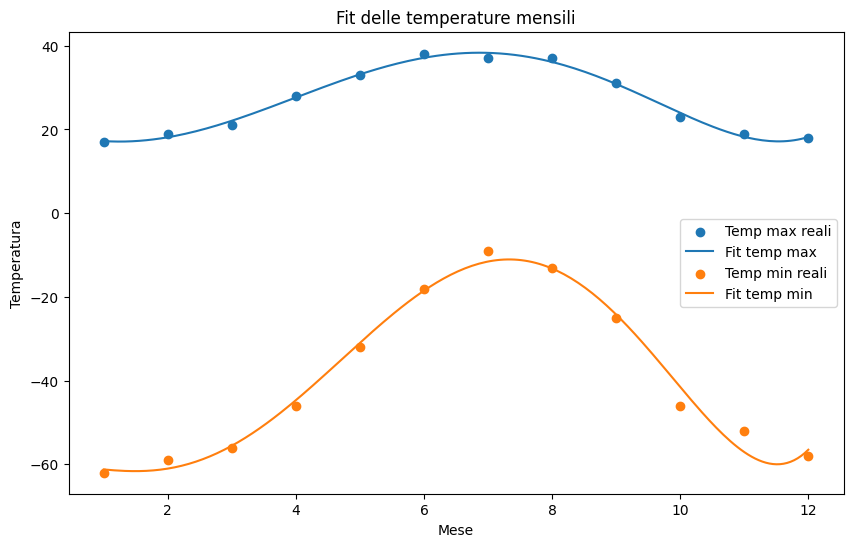

In [2]:
import numpy as np
import matplotlib.pyplot as plt

temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])

mesi = np.arange(1, 13)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

gradi = [1, 2, 3, 4, 5]

risultati_max = []
risultati_min = []

for grado in gradi:
    coeff_max = np.polyfit(mesi, temp_max, grado)
    modello_max = np.poly1d(coeff_max)
    pred_max = modello_max(mesi)

    risultati_max.append([
        grado,
        mae(temp_max, pred_max),
        rmse(temp_max, pred_max)
    ])

    coeff_min = np.polyfit(mesi, temp_min, grado)
    modello_min = np.poly1d(coeff_min)
    pred_min = modello_min(mesi)

    risultati_min.append([
        grado,
        mae(temp_min, pred_min),
        rmse(temp_min, pred_min)
    ])

risultati_max = np.array(risultati_max)
risultati_min = np.array(risultati_min)

print("Risultati temperatura massima:")
print("Grado | MAE | RMSE")
print(risultati_max)

print("Risultati temperatura minima:")
print("Grado | MAE | RMSE")
print(risultati_min)

miglior_grado_max = int(risultati_max[np.argmin(risultati_max[:, 2]), 0])
miglior_grado_min = int(risultati_min[np.argmin(risultati_min[:, 2]), 0])

print("Miglior grado per temp_max:", miglior_grado_max)
print("Miglior grado per temp_min:", miglior_grado_min)

modello_max = np.poly1d(np.polyfit(mesi, temp_max, miglior_grado_max))
modello_min = np.poly1d(np.polyfit(mesi, temp_min, miglior_grado_min))

x_line = np.linspace(1, 12, 200)

plt.figure(figsize=(10, 6))

plt.scatter(mesi, temp_max, label="Temp max reali")
plt.plot(x_line, modello_max(x_line), label="Fit temp max")

plt.scatter(mesi, temp_min, label="Temp min reali")
plt.plot(x_line, modello_min(x_line), label="Fit temp min")

plt.title("Fit delle temperature mensili")
plt.xlabel("Mese")
plt.ylabel("Temperatura")
plt.legend()
plt.show()

### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

In [3]:
import pandas as pd

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df


,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


Intercetta: 29.59985475616395
Coefficiente: -0.041215119962786144
MAE: 2.6054734857610677
RMSE: 3.1482072740002796
R²: 0.7183433404897299
Formula del modello:
mpg = 29.60 + (-0.0412 * disp)


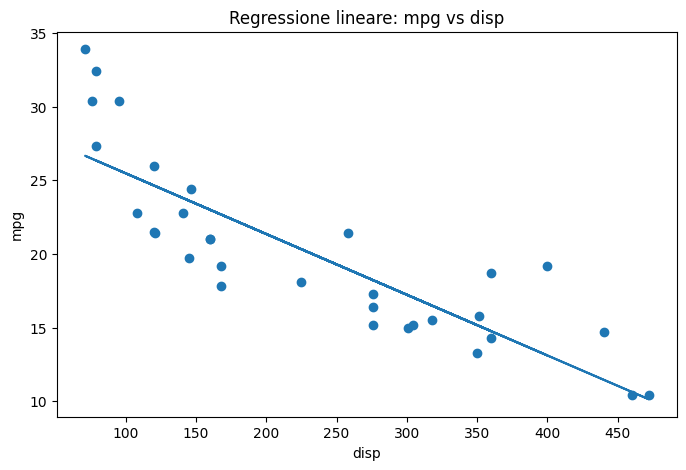

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

X = df[["disp"]]
y = df["mpg"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

intercetta = model.intercept_
coefficiente = model.coef_[0]

mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = model.score(X, y)

print("Intercetta:", intercetta)
print("Coefficiente:", coefficiente)
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

print("Formula del modello:")
print(f"mpg = {intercetta:.2f} + ({coefficiente:.4f} * disp)")

plt.figure(figsize=(8, 5))
plt.scatter(df["disp"], df["mpg"])
plt.plot(df["disp"], y_pred)
plt.title("Regressione lineare: mpg vs disp")
plt.xlabel("disp")
plt.ylabel("mpg")
plt.show()